# 1. Decision Tree Terminology
 A Decision Tree learning is a predictive modeling approach. It is used to address classification problems in statistics, data mining, and machine learning.

It is having a tree-like structure upside down and represents decisions or for decision-making. It can handle high dimension data and have good accuracy.

- The topmost node is called the root node which has no incoming edges.
- An internal node represents a test or an attribute and each branch represents an outcome of a test and each terminal node or leaf holds a class.
- It has one incoming edge and has two or more outgoing edges.
 - Terminal node or Leaf node represents a class node and has exactly one incoming node and no outgoing node.


![](https://cdn.analyticsvidhya.com/wp-content/uploads/2024/08/905753-1-1.webp)


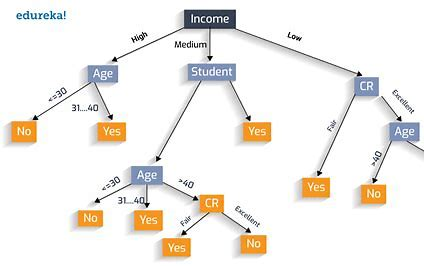



![](https://cdn.analyticsvidhya.com/wp-content/uploads/2024/08/542834-1.webp)

![](https://cdn.analyticsvidhya.com/wp-content/uploads/2024/08/618476.webp)

![](https://cdn.analyticsvidhya.com/wp-content/uploads/2024/08/784167.webp)

![](https://miro.medium.com/v2/resize:fit:2000/format:webp/1*2Od4uhmNlS6ZIhUE16Vjag.png)

![](https://miro.medium.com/v2/resize:fit:640/format:webp/1*Z-Wxuy9TiHVSOuujjoRmJA.png)

![](https://miro.medium.com/v2/resize:fit:786/format:webp/1*2fFlsoARJtQ9wqzEja4_mw.jpeg)

In [ ]:
GINI = (1- (3/4)**2 - (1/4)**2)
GINI

In [ ]:
p1 = 6/10   ## yes
p2= 4/10
p1,p2

(0.6, 0.4)

In [ ]:
gini_s = 1 - ((p1**2) + (p2**2))
gini_s

0.48

In [ ]:
# Subset 1 (X = A): 4 Positive, 1 Negative

# Subset 2 (X = B): 2 Positive, 3 Negative

# To calculate the decrease in Gini Index for this split, we initially calculate the Gini Index of every subset:

GiniS1 = 1 - (4/5)**2 - (1/5)**2

GiniS2 = 1 - (2/5)**2 - (3/5)**2   ## = 0.48

GiniS1,GiniS2


(0.31999999999999984, 0.48)

In [ ]:
gini_total = gini_s - ((5/10 * GiniS1) + (5/10 * GiniS2))

0.48 - ((0.5 * 0.32) + (0.5 * 0.48))


0.07999999999999996

In [ ]:
1- (0.75**2) - (0.25**2)

In [ ]:
0.25**2

In [ ]:
(4/9*0.375) +(5/9*0.32)

###  Information Gain¶
- The Information Gain measures the expected reduction in entropy.
- Entropy measures impurity in the data and information gain measures reduction in impurity in the data.
- The feature which has minimum impurity will be considered as the root node.

Information gain is used to decide which feature to split on at each step in building the tree.
- The creation of sub-nodes increases the homogeneity, that is decreases the entropy of these nodes.
-  The more the child node is homogeneous, the more the variance will be decreased after each split.
-  Thus Information Gain is the variance reduction and can calculate by how much the variance decreases after each split.

Information gain of a parent node can be calculated as the entropy of the parent node subtracted entropy of the weighted average of the child node.

![](https://devopedia.org/images/article/168/4250.1555312917.jpg)

In [ ]:
# read data
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings("ignore")
df1 = pd.read_csv('https://github.com/YBIFoundation/Dataset/raw/main/Admission%20Chance.csv')
df1.head()

,Serial No,GRE Score,TOEFL Score,University Rating,SOP,LOR,CGPA,Research,Chance of Admit
0,1,337,118,4,4.5,4.5,9.65,1,0.92
1,2,324,107,4,4.0,4.5,8.87,1,0.76
2,3,316,104,3,3.0,3.5,8.00,1,0.72
3,4,322,110,3,3.5,2.5,8.67,1,0.80
4,5,314,103,2,2.0,3.0,8.21,0,0.65


In [ ]:
df1.columns

Index(['Serial No', 'GRE Score', 'TOEFL Score', 'University Rating', ' SOP',
       'LOR ', 'CGPA', 'Research', 'Chance of Admit '],
      dtype='object')

In [ ]:
df1["Chance of Admit "].unique()

array([0.92, 0.76, 0.72, 0.8 , 0.65, 0.9 , 0.75, 0.68, 0.5 , 0.45, 0.52,
       0.84, 0.78, 0.62, 0.61, 0.54, 0.66, 0.63, 0.64, 0.7 , 0.94, 0.95,
       0.97, 0.44, 0.46, 0.74, 0.91, 0.88, 0.58, 0.48, 0.49, 0.53, 0.87,
       0.86, 0.89, 0.82, 0.56, 0.36, 0.42, 0.47, 0.55, 0.57, 0.96, 0.93,
       0.38, 0.34, 0.79, 0.71, 0.69, 0.59, 0.85, 0.77, 0.81, 0.83, 0.67,
       0.73, 0.6 , 0.43, 0.51, 0.39])

In [ ]:
df1["TOEFL Score"].max()

120

In [ ]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Serial No          400 non-null    int64  
 1   GRE Score          400 non-null    int64  
 2   TOEFL Score        400 non-null    int64  
 3   University Rating  400 non-null    int64  
 4    SOP               400 non-null    float64
 5   LOR                400 non-null    float64
 6   CGPA               400 non-null    float64
 7   Research           400 non-null    int64  
 8   Chance of Admit    400 non-null    float64
dtypes: float64(4), int64(5)
memory usage: 28.3 KB


In [ ]:
df1.isna().sum()

Serial No            0
GRE Score            0
TOEFL Score          0
University Rating    0
 SOP                 0
LOR                  0
CGPA                 0
Research             0
Chance of Admit      0
dtype: int64

In [ ]:
df1.duplicated().sum()

0

In [ ]:
x = df1.drop(["Chance of Admit "],axis = 1)
y = df1["Chance of Admit "]
x

,Serial No,GRE Score,TOEFL Score,University Rating,SOP,LOR,CGPA,Research
0,1,337,118,4,4.5,4.5,9.65,1
1,2,324,107,4,4.0,4.5,8.87,1
2,3,316,104,3,3.0,3.5,8.00,1
3,4,322,110,3,3.5,2.5,8.67,1
4,5,314,103,2,2.0,3.0,8.21,0
...,...,...,...,...,...,...,...,...
395,396,324,110,3,3.5,3.5,9.04,1
396,397,325,107,3,3.0,3.5,9.11,1
397,398,330,116,4,5.0,4.5,9.45,1
398,399,312,103,3,3.5,4.0,8.78,0


In [ ]:
from sklearn.preprocessing import MinMaxScaler
mn = MinMaxScaler()
mn

MinMaxScaler()

In [ ]:
x = mn.fit_transform(x)
x

array([[0.        , 0.94      , 0.92857143, ..., 0.875     , 0.91346154,
        1.        ],
       [0.00250627, 0.68      , 0.53571429, ..., 0.875     , 0.66346154,
        1.        ],
       [0.00501253, 0.52      , 0.42857143, ..., 0.625     , 0.38461538,
        1.        ],
       ...,
       [0.99498747, 0.8       , 0.85714286, ..., 0.875     , 0.84935897,
        1.        ],
       [0.99749373, 0.44      , 0.39285714, ..., 0.75      , 0.63461538,
        0.        ],
       [1.        , 0.86      , 0.89285714, ..., 0.75      , 0.91666667,
        1.        ]])

In [ ]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size = 0.25,random_state = 421)

In [ ]:
x_train.shape

(300, 8)

In [ ]:
x_test.shape

(100, 8)

In [ ]:
from sklearn.tree import DecisionTreeRegressor
from sklearn import tree
from sklearn.metrics import  r2_score
dr = DecisionTreeRegressor(criterion= "gini" or 'entropy')
dr.fit(x_train,y_train)


DecisionTreeRegressor()

In [ ]:
y_pred = dr.predict(x_test)
y_pred

array([0.9 , 0.81, 0.61, 0.89, 0.47, 0.84, 0.68, 0.68, 0.81, 0.89, 0.95,
       0.57, 0.94, 0.91, 0.97, 0.95, 0.52, 0.7 , 0.92, 0.77, 0.34, 0.76,
       0.75, 0.55, 0.48, 0.75, 0.9 , 0.8 , 0.58, 0.73, 0.91, 0.62, 0.72,
       0.57, 0.62, 0.65, 0.74, 0.52, 0.72, 0.75, 0.75, 0.73, 0.86, 0.69,
       0.59, 0.65, 0.79, 0.64, 0.7 , 0.68, 0.72, 0.54, 0.75, 0.8 , 0.94,
       0.7 , 0.53, 0.72, 0.56, 0.59, 0.72, 0.34, 0.68, 0.72, 0.56, 0.58,
       0.62, 0.65, 0.76, 0.73, 0.68, 0.53, 0.73, 0.53, 0.84, 0.91, 0.9 ,
       0.73, 0.8 , 0.97, 0.53, 0.89, 0.8 , 0.44, 0.9 , 0.34, 0.69, 0.72,
       0.49, 0.52, 0.6 , 0.78, 0.57, 0.77, 0.94, 0.77, 0.76, 0.74, 0.52,
       0.86])

In [ ]:
r2_score(y_test,y_pred)

0.49808092849002494

In [ ]:
clf_gini = DecisionTreeRegressor(criterion= "squared_error",max_depth = 3)
clf_gini_fit = clf_gini.fit(x_train,y_train)

In [ ]:
clf_pred =  clf_gini_fit.predict(x_test)
r2_score(y_test,clf_pred)

0.6963790068133724

[Text(0.5, 0.875, 'x[6] <= 0.611\nsquared_error = 0.021\nsamples = 300\nvalue = 0.727'),
 Text(0.25, 0.625, 'x[6] <= 0.396\nsquared_error = 0.012\nsamples = 168\nvalue = 0.633'),
 Text(0.125, 0.375, 'x[1] <= 0.35\nsquared_error = 0.009\nsamples = 59\nvalue = 0.544'),
 Text(0.0625, 0.125, 'squared_error = 0.007\nsamples = 37\nvalue = 0.508'),
 Text(0.1875, 0.125, 'squared_error = 0.006\nsamples = 22\nvalue = 0.604'),
 Text(0.375, 0.375, 'x[0] <= 0.32\nsquared_error = 0.006\nsamples = 109\nvalue = 0.681'),
 Text(0.3125, 0.125, 'squared_error = 0.009\nsamples = 29\nvalue = 0.613'),
 Text(0.4375, 0.125, 'squared_error = 0.003\nsamples = 80\nvalue = 0.705'),
 Text(0.75, 0.625, 'x[6] <= 0.777\nsquared_error = 0.006\nsamples = 132\nvalue = 0.846'),
 Text(0.625, 0.375, 'x[4] <= 0.688\nsquared_error = 0.004\nsamples = 87\nvalue = 0.803'),
 Text(0.5625, 0.125, 'squared_error = 0.004\nsamples = 36\nvalue = 0.763'),
 Text(0.6875, 0.125, 'squared_error = 0.002\nsamples = 51\nvalue = 0.832'),
 Text(

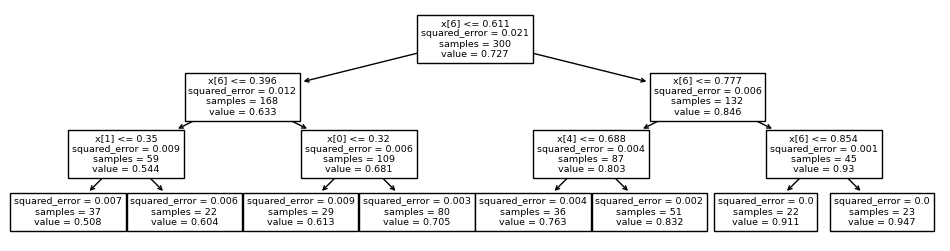

In [ ]:
import matplotlib.pyplot as plt
plt.figure(figsize = (12,3))
tree.plot_tree(clf_gini_fit )

In [ ]:
import pandas as pd
df2 = pd.read_csv(r"C:\Users\Rahul\Downloads\mushrooms.csv")
df2.head()

,class,cap-shape,cap-surface,cap-color,bruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,...,stalk-surface-below-ring,stalk-color-above-ring,stalk-color-below-ring,veil-type,veil-color,ring-number,ring-type,spore-print-color,population,habitat
0,p,x,s,n,t,p,f,c,n,k,...,s,w,w,p,w,o,p,k,s,u
1,e,x,s,y,t,a,f,c,b,k,...,s,w,w,p,w,o,p,n,n,g
2,e,b,s,w,t,l,f,c,b,n,...,s,w,w,p,w,o,p,n,n,m
3,p,x,y,w,t,p,f,c,n,n,...,s,w,w,p,w,o,p,k,s,u
4,e,x,s,g,f,n,f,w,b,k,...,s,w,w,p,w,o,e,n,a,g


In [ ]:
df1.isnull().sum()

Serial No            0
GRE Score            0
TOEFL Score          0
University Rating    0
 SOP                 0
LOR                  0
CGPA                 0
Research             0
Chance of Admit      0
dtype: int64

In [ ]:
df1.shape

(400, 9)

In [ ]:
# df2["class"].unique()

array(['p', 'e'], dtype=object)

The class column is target and it has two clasification which describes if mushroom is poisonous or edible. In class column posionous is p and edible is e.

In [ ]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Serial No          400 non-null    int64  
 1   GRE Score          400 non-null    int64  
 2   TOEFL Score        400 non-null    int64  
 3   University Rating  400 non-null    int64  
 4    SOP               400 non-null    float64
 5   LOR                400 non-null    float64
 6   CGPA               400 non-null    float64
 7   Research           400 non-null    int64  
 8   Chance of Admit    400 non-null    float64
dtypes: float64(4), int64(5)
memory usage: 28.3 KB


In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

class
e    0.517971
p    0.482029
Name: proportion, dtype: float64

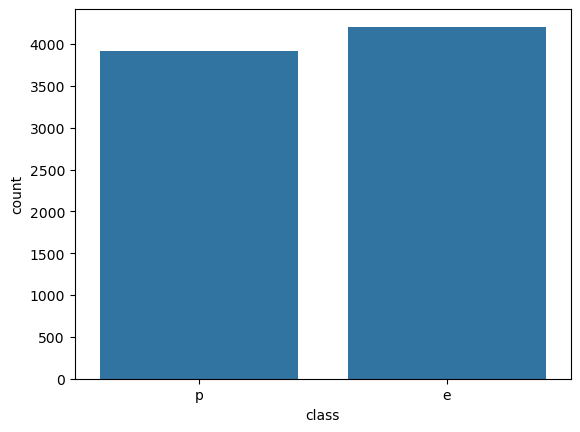

In [ ]:
# sns.countplot(x = "class",data = df2);
# df2["class"].value_counts(normalize = True)

In [ ]:
# x = df.drop(["class"],axis = 1)
# y = df["class"]

In [ ]:
# x = pd.get_dummies(x)
# x = x.astype(int)
# x.head()

In [ ]:
# from sklearn.preprocessing import LabelEncoder
# en = LabelEncoder()
# y = en.fit_transform(y)
# y

In [ ]:
x = df1.drop(['Serial No',"Chance of Admit "],axis = 1)
y = df1["Chance of Admit "]
y

0      0.92
1      0.76
2      0.72
3      0.80
4      0.65
       ... 
395    0.82
396    0.84
397    0.91
398    0.67
399    0.95
Name: Chance of Admit , Length: 400, dtype: float64

In [ ]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2,random_state = 100)

In [ ]:
from sklearn.tree import DecisionTreeRegressor
from sklearn import tree
from sklearn.metrics import  r2_score

[Text(0.5491071428571429, 0.9166666666666666, 'x[5] <= 8.655\nsquared_error = 0.021\nsamples = 320\nvalue = 0.726'),
 Text(0.2857142857142857, 0.75, 'x[5] <= 8.035\nsquared_error = 0.012\nsamples = 171\nvalue = 0.628'),
 Text(0.14285714285714285, 0.5833333333333334, 'x[5] <= 7.665\nsquared_error = 0.01\nsamples = 58\nvalue = 0.533'),
 Text(0.07142857142857142, 0.4166666666666667, 'x[5] <= 7.655\nsquared_error = 0.006\nsamples = 21\nvalue = 0.466'),
 Text(0.03571428571428571, 0.25, 'x[0] <= 301.0\nsquared_error = 0.005\nsamples = 18\nvalue = 0.482'),
 Text(0.017857142857142856, 0.08333333333333333, 'squared_error = 0.003\nsamples = 9\nvalue = 0.442'),
 Text(0.05357142857142857, 0.08333333333333333, 'squared_error = 0.003\nsamples = 9\nvalue = 0.521'),
 Text(0.10714285714285714, 0.25, 'x[2] <= 2.5\nsquared_error = 0.0\nsamples = 3\nvalue = 0.373'),
 Text(0.08928571428571429, 0.08333333333333333, 'squared_error = 0.0\nsamples = 1\nvalue = 0.38'),
 Text(0.125, 0.08333333333333333, 'squared

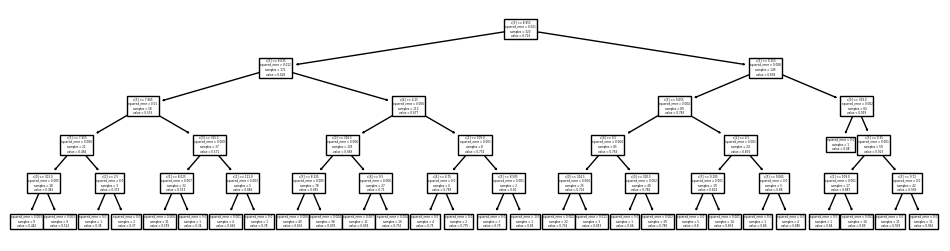

In [ ]:
plt.figure(figsize = (12,3))
tree.plot_tree(clf_gini_fit )

In [ ]:
y_pred_gini = clf_gini.predict(x_test)
y_pred_gini

array([0.78923077, 0.78923077, 0.89      , 0.89      , 0.636     ,
       0.89      , 0.67578947, 0.78923077, 0.89      , 0.55935484,
       0.66      , 0.73590909, 0.636     , 0.67818182, 0.636     ,
       0.67578947, 0.89      , 0.636     , 0.55935484, 0.8       ,
       0.636     , 0.78923077, 0.44222222, 0.83285714, 0.44222222,
       0.73590909, 0.78923077, 0.78923077, 0.52111111, 0.92903226,
       0.89      , 0.78923077, 0.73590909, 0.67578947, 0.55935484,
       0.55935484, 0.55935484, 0.78923077, 0.92903226, 0.44222222,
       0.67578947, 0.6625    , 0.731875  , 0.34      , 0.78923077,
       0.44222222, 0.636     , 0.89      , 0.34      , 0.55935484,
       0.92903226, 0.731875  , 0.83285714, 0.78923077, 0.78923077,
       0.89      , 0.44222222, 0.67818182, 0.73590909, 0.73590909,
       0.885     , 0.44222222, 0.636     , 0.78923077, 0.636     ,
       0.731875  , 0.78923077, 0.67578947, 0.636     , 0.731875  ,
       0.92903226, 0.67578947, 0.65333333, 0.636     , 0.89   

In [ ]:
from sklearn.metrics import r2_score
y_pred_train_gini = clf_gini.predict(x_train)

y_pred_train_gini

array([0.89      , 0.89      , 0.75      , 0.44222222, 0.92903226,
       0.67578947, 0.73590909, 0.78923077, 0.67578947, 0.44222222,
       0.67818182, 0.52111111, 0.73590909, 0.83285714, 0.44222222,
       0.78923077, 0.84      , 0.67578947, 0.6625    , 0.731875  ,
       0.67818182, 0.78923077, 0.96181818, 0.92903226, 0.55935484,
       0.78923077, 0.55935484, 0.67578947, 0.636     , 0.636     ,
       0.67578947, 0.636     , 0.86      , 0.92903226, 0.83285714,
       0.55935484, 0.636     , 0.55935484, 0.731875  , 0.67578947,
       0.89      , 0.885     , 0.885     , 0.92903226, 0.73590909,
       0.55935484, 0.92903226, 0.92903226, 0.636     , 0.636     ,
       0.78923077, 0.67578947, 0.636     , 0.67578947, 0.73590909,
       0.73590909, 0.89      , 0.78923077, 0.55935484, 0.83285714,
       0.73590909, 0.731875  , 0.636     , 0.92903226, 0.44222222,
       0.78923077, 0.65333333, 0.636     , 0.92903226, 0.55935484,
       0.83285714, 0.636     , 0.636     , 0.67578947, 0.78923

In [ ]:
print('Model accuracy score with criterion gini index: {0:0.4f}'. format(r2_score(y_test, y_pred_gini)))
#Accuracy Score for training set
print('Training-set accuracy score: {0:0.4f}'. format(r2_score(y_train, y_pred_train_gini)))

Model accuracy score with criterion gini index: 0.6269
Training-set accuracy score: 0.8603


In [ ]:
0.6992 test
0.8645  training

SyntaxError: invalid syntax (3486967796.py, line 1)

In [ ]:
# from sklearn.tree import DecisionTreeClassifier
# from sklearn import tree
# from sklearn.metrics import accuracy_score

In [ ]:
# clf_gini = DecisionTreeClassifier(criterion= "gini",max_depth = 3,random_state = 0)
# clf_gini_fit = clf_gini.fit(x_train,y_train)

In [ ]:
# plt.figure(figsize = (12,3))
# tree.plot_tree(clf_gini_fit )

In [ ]:
# y_pred_gini = clf_gini.predict(x_test)
# y_pred_gini

In [ ]:
# y_pred_train_gini = clf_gini.predict(x_train)

# y_pred_train_gini

In [ ]:
# from sklearn.metrics import confusion_matrix
# confusion_matrix(y_test,y_pred_gini)

In [ ]:
# print('Model accuracy score with criterion gini index: {0:0.4f}'. format(accuracy_score(y_test, y_pred_gini)))
# #Accuracy Score for training set
# print('Training-set accuracy score: {0:0.4f}'. format(accuracy_score(y_train, y_pred_train_gini)))

In [ ]:
# clf_en = DecisionTreeClassifier(criterion='entropy', max_depth=3, random_state=0)


# # fit the model
# clf_en.fit(x_train, y_train)

In [ ]:
plt.figure(figsize=(12,8))
tree.plot_tree(clf_en.fit(x_train, y_train))

In [ ]:
#Predict the values
y_pred_en = clf_en.predict(x_test)


In [ ]:
#Predict the value using X train for accuracy comparision
y_pred_train_en = clf_en.predict(x_train)

In [ ]:
print('Model accuracy score with criterion entropy: {0:0.4f}'. format(accuracy_score(y_test, y_pred_en)))
print('Training-set accuracy score: {0:0.4f}'. format(accuracy_score(y_train, y_pred_train_en)))

In [ ]:
print('Training set score: {:.4f}'.format(clf_en.score(x_train, y_train)))
print('Test set score: {:.4f}'.format(clf_en.score(x_test, y_test)))

In [ ]:
cm = confusion_matrix(y_test, y_pred_en)

print('Confusion matrix\n\n', cm)

In [ ]:
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred_en))

Decision-Tree Classifier model using both gini index and entropy have only very very small difference in model accuracy and training set accuracy, so there is no sign of overfitting.